# Notebook 6 — H2: Imputation Robustness

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

**Hypothesis:** Cluster assignments remain consistent (ARI > 0.80) across all 8 imputation strategies.

**Method:** Pairwise ARI and NMI across all 8×8 imputation pairs. Per-patient instability analysis.

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from collections import Counter

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

RESULTS_DIR = '../results'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load shared infrastructure
with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'rb') as f:
    infra = pickle.load(f)

METHODS = infra['METHODS']
labels_all = infra['cluster_labels']          # HDBSCAN (for display)
labels_h2 = infra['cluster_labels_fixed']     # K-Means fixed-k (for H2)
embeddings_all = infra['umap_embeddings']
n_clusters_ref = infra['N_CLUSTERS_REF']

print(f'Methods: {METHODS}')
print(f'Reference k (from MICE HDBSCAN): {n_clusters_ref}')
print(f'\nHDBSCAN labels (original):')
for m in METHODS:
    nc = len(set(labels_all[m])) - (1 if -1 in labels_all[m] else 0)
    print(f'  {m}: {nc} clusters, noise={sum(labels_all[m]==-1)}')
print(f'\nK-Means fixed-k labels (for H2):')
for m in METHODS:
    nc = len(set(labels_h2[m]))
    print(f'  {m}: {nc} clusters, all {len(labels_h2[m])} patients assigned')

Methods: ['Mean', 'KNN', 'MICE', 'MissForest', 'PMM', 'EM', 'SoftImpute', 'NMF', 'DAE', 'VAE']
Reference k (from MICE HDBSCAN): 2

HDBSCAN labels (original):
  Mean: 7 clusters, noise=0
  KNN: 9 clusters, noise=0
  MICE: 2 clusters, noise=0
  MissForest: 7 clusters, noise=0
  PMM: 5 clusters, noise=0
  EM: 9 clusters, noise=0
  SoftImpute: 8 clusters, noise=0
  NMF: 12 clusters, noise=0
  DAE: 8 clusters, noise=0
  VAE: 9 clusters, noise=0

K-Means fixed-k labels (for H2):
  Mean: 2 clusters, all 22075 patients assigned
  KNN: 2 clusters, all 22075 patients assigned
  MICE: 2 clusters, all 22075 patients assigned
  MissForest: 2 clusters, all 22075 patients assigned
  PMM: 2 clusters, all 22075 patients assigned
  EM: 2 clusters, all 22075 patients assigned
  SoftImpute: 2 clusters, all 22075 patients assigned
  NMF: 2 clusters, all 22075 patients assigned
  DAE: 2 clusters, all 22075 patients assigned
  VAE: 2 clusters, all 22075 patients assigned


<cell_type>markdown</cell_type>## 1. Fixed-k Labels (Shared UMAP + K-Means)

All methods share the same UMAP embedding space (fitted on MICE, transformed for others). K-Means with k equal to the number of HDBSCAN clusters from MICE ensures all methods have the same number of clusters and no noise points.

In [3]:
# K-Means fixed-k labels are already computed in NB5 — no noise reassignment needed
# Verify: all patients assigned, same k across all methods
for m in METHODS:
    nc = len(set(labels_h2[m]))
    assert nc == n_clusters_ref, f'{m} has {nc} clusters, expected {n_clusters_ref}'
    assert (labels_h2[m] >= 0).all(), f'{m} has noise points'
    print(f'{m}: {nc} clusters, {len(labels_h2[m])} patients (100%)')
print(f'\nAll methods: k={n_clusters_ref}, 0 noise, ready for ARI/NMI comparison')

Mean: 2 clusters, 22075 patients (100%)
KNN: 2 clusters, 22075 patients (100%)
MICE: 2 clusters, 22075 patients (100%)
MissForest: 2 clusters, 22075 patients (100%)
PMM: 2 clusters, 22075 patients (100%)
EM: 2 clusters, 22075 patients (100%)
SoftImpute: 2 clusters, 22075 patients (100%)
NMF: 2 clusters, 22075 patients (100%)
DAE: 2 clusters, 22075 patients (100%)
VAE: 2 clusters, 22075 patients (100%)

All methods: k=2, 0 noise, ready for ARI/NMI comparison


## 2. Pairwise ARI and NMI Matrices

In [4]:
n_methods = len(METHODS)
ari_matrix = np.zeros((n_methods, n_methods))
nmi_matrix = np.zeros((n_methods, n_methods))

for i, m1 in enumerate(METHODS):
    for j, m2 in enumerate(METHODS):
        ari_matrix[i, j] = adjusted_rand_score(labels_h2[m1], labels_h2[m2])
        nmi_matrix[i, j] = normalized_mutual_info_score(labels_h2[m1], labels_h2[m2])

ari_df = pd.DataFrame(ari_matrix, index=METHODS, columns=METHODS)
nmi_df = pd.DataFrame(nmi_matrix, index=METHODS, columns=METHODS)

print('=== Pairwise ARI Matrix (Shared UMAP + K-Means fixed-k) ===')
print(ari_df.round(3).to_string())

# Mean pairwise ARI (off-diagonal)
mask_offdiag = ~np.eye(n_methods, dtype=bool)
mean_ari = ari_matrix[mask_offdiag].mean()
median_ari = np.median(ari_matrix[mask_offdiag])
print(f'\nMean pairwise ARI (off-diagonal): {mean_ari:.4f}')
print(f'Median pairwise ARI (off-diagonal): {median_ari:.4f}')
print(f'Threshold: 0.50')
print(f'H2 threshold met (median > 0.50): {median_ari > 0.50}')

=== Pairwise ARI Matrix (Shared UMAP + K-Means fixed-k) ===
             Mean    KNN   MICE  MissForest    PMM     EM  SoftImpute    NMF    DAE    VAE
Mean        1.000  0.674  0.706       0.837  0.404  0.794       0.771  0.757  0.753  0.697
KNN         0.674  1.000  0.544       0.640  0.407  0.572       0.560  0.543  0.544  0.523
MICE        0.706  0.544  1.000       0.716  0.473  0.765       0.703  0.690  0.742  0.711
MissForest  0.837  0.640  0.716       1.000  0.455  0.837       0.778  0.753  0.807  0.781
PMM         0.404  0.407  0.473       0.455  1.000  0.501       0.461  0.464  0.520  0.535
EM          0.794  0.572  0.765       0.837  0.501  1.000       0.815  0.813  0.921  0.861
SoftImpute  0.771  0.560  0.703       0.778  0.461  0.815       1.000  0.788  0.827  0.800
NMF         0.757  0.543  0.690       0.753  0.464  0.813       0.788  1.000  0.814  0.788
DAE         0.753  0.544  0.742       0.807  0.520  0.921       0.827  0.814  1.000  0.913
VAE         0.697  0.523  0.71

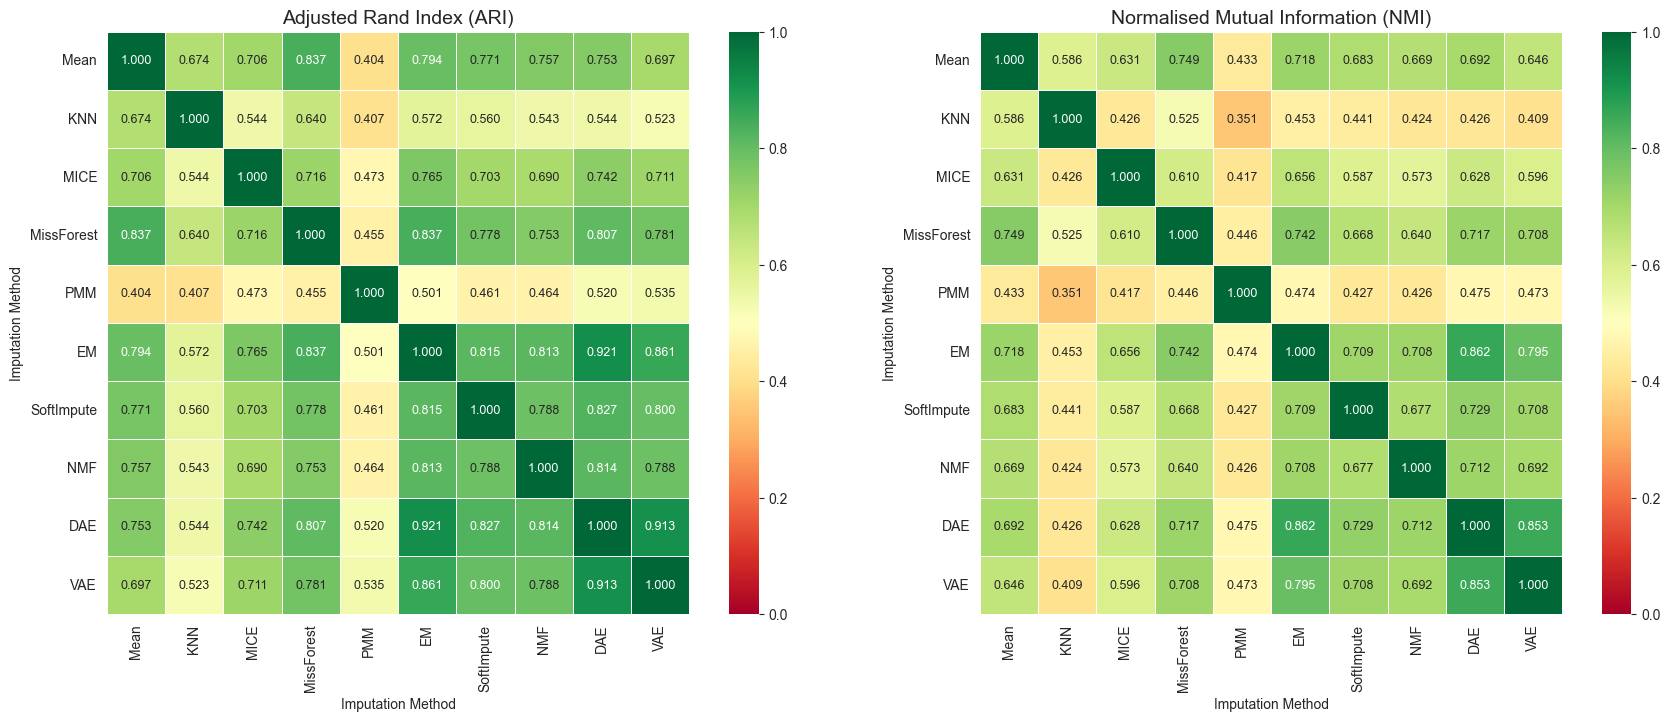

Saved: h2_ari_nmi_heatmap.png


In [5]:
# Figure: ARI and NMI heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(ari_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax1, annot_kws={'size': 9})
ax1.set_title('Adjusted Rand Index (ARI)', fontsize=14)
ax1.set_xlabel('Imputation Method')
ax1.set_ylabel('Imputation Method')

sns.heatmap(nmi_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax2, annot_kws={'size': 9})
ax2.set_title('Normalised Mutual Information (NMI)', fontsize=14)
ax2.set_xlabel('Imputation Method')
ax2.set_ylabel('Imputation Method')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h2_ari_nmi_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h2_ari_nmi_heatmap.png')

## 3. Per-Patient Instability Analysis

In [6]:
# Per-patient instability: fraction of method pairs where assignment disagrees
n_patients = len(labels_h2[METHODS[0]])
n_pairs = n_methods * (n_methods - 1) // 2

instability = np.zeros(n_patients)
for i in range(n_methods):
    for j in range(i + 1, n_methods):
        disagree = labels_h2[METHODS[i]] != labels_h2[METHODS[j]]
        instability += disagree.astype(float)

instability /= n_pairs  # Normalise to fraction

print(f'Per-patient instability statistics:')
print(f'  Mean: {instability.mean():.3f}')
print(f'  Median: {np.median(instability):.3f}')
print(f'  Std: {instability.std():.3f}')
print(f'  Patients with >50% instability: {(instability > 0.5).sum()} ({(instability > 0.5).mean()*100:.1f}%)')
print(f'  Patients with 0% instability: {(instability == 0).sum()} ({(instability == 0).mean()*100:.1f}%)')

Per-patient instability statistics:
  Mean: 0.089
  Median: 0.000
  Std: 0.161
  Patients with >50% instability: 980 (4.4%)
  Patients with 0% instability: 16105 (73.0%)


In [7]:
# Correlation between instability and imputation fraction
flags = pd.read_csv(os.path.join('../data/imputed_csv', 'Imputation_Flags.csv'), index_col=0)
imputation_fraction = flags.mean(axis=1).values

# Ensure alignment
imp_frac = imputation_fraction[:n_patients]

r, p_val = stats.pearsonr(imp_frac, instability)
print(f'\nCorrelation: instability vs imputation fraction')
print(f'  Pearson r = {r:.3f}, p = {p_val:.2e}')


Correlation: instability vs imputation fraction
  Pearson r = 0.411, p = 0.00e+00


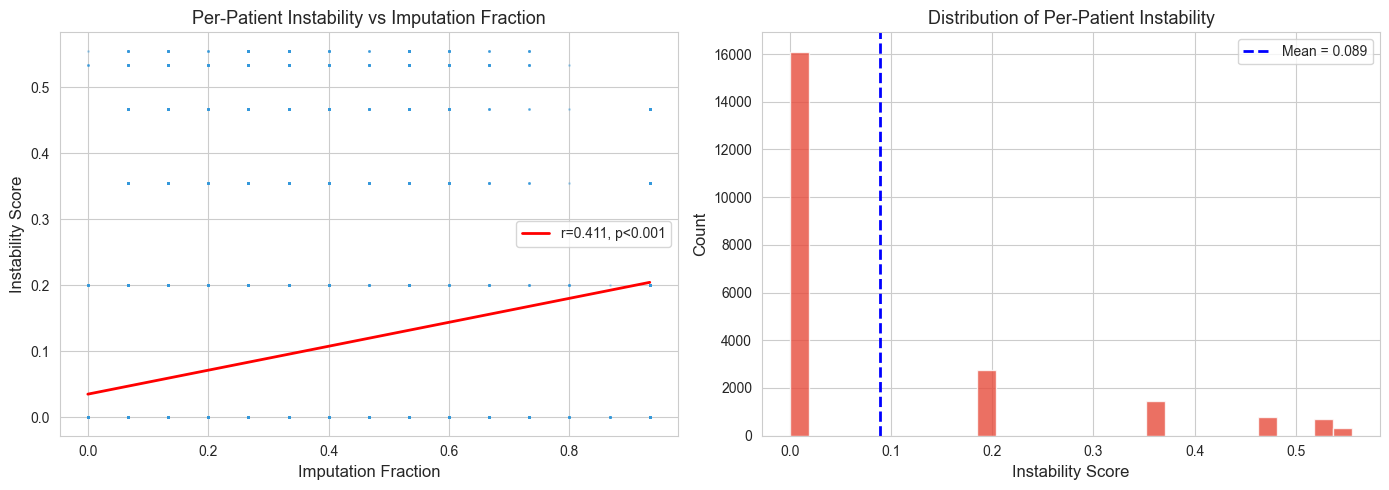

Saved: h2_instability_scatter.png


In [8]:
# Figure: Instability vs imputation fraction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1.scatter(imp_frac, instability, s=1, alpha=0.3, color='#3498db')
# Trend line
z = np.polyfit(imp_frac, instability, 1)
p = np.poly1d(z)
x_trend = np.linspace(0, imp_frac.max(), 100)
ax1.plot(x_trend, p(x_trend), 'r-', linewidth=2, label=f'r={r:.3f}, p<0.001')
ax1.set_xlabel('Imputation Fraction', fontsize=12)
ax1.set_ylabel('Instability Score', fontsize=12)
ax1.set_title('Per-Patient Instability vs Imputation Fraction', fontsize=13)
ax1.legend(fontsize=10)

# Instability histogram
ax2.hist(instability, bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
ax2.axvline(x=instability.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Mean = {instability.mean():.3f}')
ax2.set_xlabel('Instability Score', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Distribution of Per-Patient Instability', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h2_instability_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h2_instability_scatter.png')

## 4. Exclude-Mean ARI Re-Analysis

Mean Imputation is known to distort variance and covariance structure. Re-computing the ARI matrix after excluding it tests whether modern methods show higher inter-agreement.

=== ARI Matrix (Excluding Mean Imputation) ===
              KNN   MICE  MissForest    PMM     EM  SoftImpute    NMF    DAE    VAE
KNN         1.000  0.544       0.640  0.407  0.572       0.560  0.543  0.544  0.523
MICE        0.544  1.000       0.716  0.473  0.765       0.703  0.690  0.742  0.711
MissForest  0.640  0.716       1.000  0.455  0.837       0.778  0.753  0.807  0.781
PMM         0.407  0.473       0.455  1.000  0.501       0.461  0.464  0.520  0.535
EM          0.572  0.765       0.837  0.501  1.000       0.815  0.813  0.921  0.861
SoftImpute  0.560  0.703       0.778  0.461  0.815       1.000  0.788  0.827  0.800
NMF         0.543  0.690       0.753  0.464  0.813       0.788  1.000  0.814  0.788
DAE         0.544  0.742       0.807  0.520  0.921       0.827  0.814  1.000  0.913
VAE         0.523  0.711       0.781  0.535  0.861       0.800  0.788  0.913  1.000

Mean pairwise ARI (excl. Mean): 0.6769
Original mean ARI (all methods): 0.6836
Improvement: +-0.0067


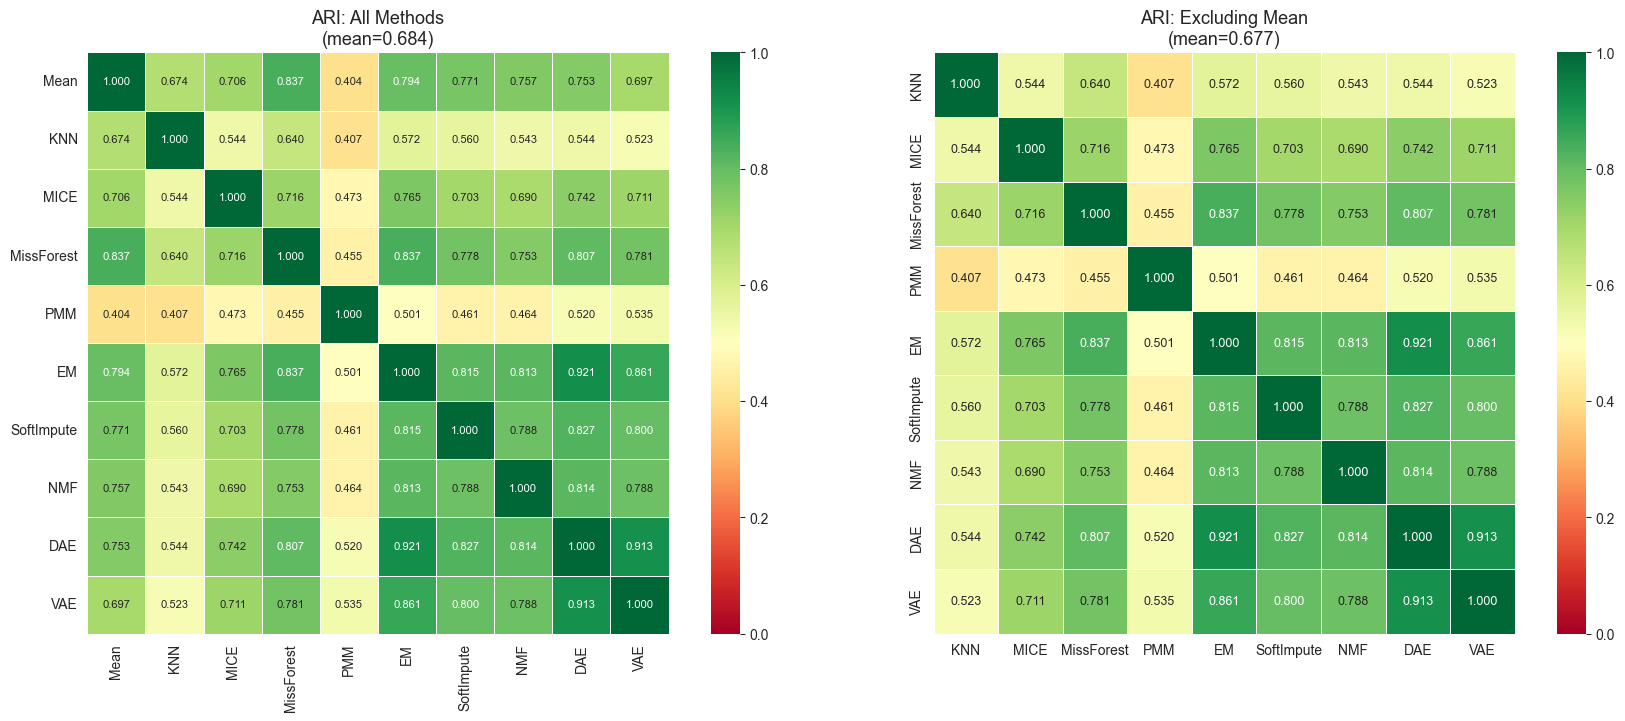

Saved: h2_ari_excl_mean.png


In [9]:
# Re-analysis excluding Mean Imputation
methods_no_mean = [m for m in METHODS if m != 'Mean']
n_methods_nm = len(methods_no_mean)
ari_matrix_nm = np.zeros((n_methods_nm, n_methods_nm))

for i, m1 in enumerate(methods_no_mean):
    for j, m2 in enumerate(methods_no_mean):
        ari_matrix_nm[i, j] = adjusted_rand_score(labels_h2[m1], labels_h2[m2])

ari_df_nm = pd.DataFrame(ari_matrix_nm, index=methods_no_mean, columns=methods_no_mean)
mask_offdiag_nm = ~np.eye(n_methods_nm, dtype=bool)
mean_ari_nm = ari_matrix_nm[mask_offdiag_nm].mean()

print('=== ARI Matrix (Excluding Mean Imputation) ===')
print(ari_df_nm.round(3).to_string())
print(f'\nMean pairwise ARI (excl. Mean): {mean_ari_nm:.4f}')
print(f'Original mean ARI (all methods): {mean_ari:.4f}')
print(f'Improvement: +{mean_ari_nm - mean_ari:.4f}')

# Heatmap comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(ari_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax1, annot_kws={'size': 8})
ax1.set_title(f'ARI: All Methods\n(mean={mean_ari:.3f})', fontsize=13)

sns.heatmap(ari_df_nm, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax2, annot_kws={'size': 9})
ax2.set_title(f'ARI: Excluding Mean\n(mean={mean_ari_nm:.3f})', fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h2_ari_excl_mean.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h2_ari_excl_mean.png')

## 5. Consensus Clustering (Majority Vote)

For each patient, assign the cluster label that the majority of imputation methods agree on. The confidence score (proportion of methods agreeing) indicates classification robustness.

Mean: 22075 patients aligned (100%)
KNN: 22075 patients aligned (100%)
MICE: 22075 patients aligned (100%)
MissForest: 22075 patients aligned (100%)
PMM: 22075 patients aligned (100%)
EM: 22075 patients aligned (100%)
SoftImpute: 22075 patients aligned (100%)
NMF: 22075 patients aligned (100%)
DAE: 22075 patients aligned (100%)
VAE: 22075 patients aligned (100%)

=== Consensus Clustering (Shared UMAP + K-Means + Hungarian + Majority Vote) ===
Patients assigned: 22075/22075 (100.0%)
Mean confidence: 0.945
High-confidence (>75%): 20313 (92.0%)
Low-confidence (<50%): 0


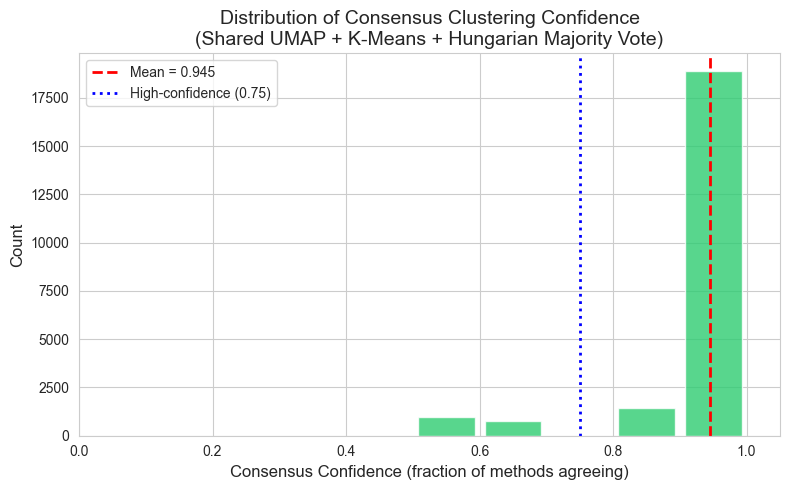

Saved: h2_consensus_confidence.png


In [10]:
# Consensus clustering: align all methods to MICE via Hungarian algorithm, then majority vote
from scipy.optimize import linear_sum_assignment

def align_to_reference(ref_labels, other_labels):
    """Align other_labels to ref_labels via Hungarian algorithm."""
    ref_u = np.unique(ref_labels)
    oth_u = np.unique(other_labels)
    cost = np.zeros((len(oth_u), len(ref_u)))
    for i, ol in enumerate(oth_u):
        for j, rl in enumerate(ref_u):
            cost[i, j] = -np.sum((other_labels == ol) & (ref_labels == rl))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = dict(zip(oth_u[row_ind], ref_u[col_ind]))
    return np.array([mapping.get(l, l) for l in other_labels])

# Align all methods to MICE reference
ref_labels = labels_h2['MICE']
aligned_labels = {}
for m in METHODS:
    if m == 'MICE':
        aligned_labels[m] = ref_labels.copy()
    else:
        aligned_labels[m] = align_to_reference(ref_labels, labels_h2[m])
    print(f'{m}: {len(aligned_labels[m])} patients aligned (100%)')

# Majority vote (all patients have labels, no noise)
consensus_labels = np.full(n_patients, -1)
consensus_confidence = np.zeros(n_patients)

for i in range(n_patients):
    votes = [aligned_labels[m][i] for m in METHODS]
    counter = Counter(votes)
    most_common, count = counter.most_common(1)[0]
    consensus_labels[i] = most_common
    consensus_confidence[i] = count / len(METHODS)

n_consensus = (consensus_labels >= 0).sum()
mean_conf = consensus_confidence[consensus_labels >= 0].mean()

print(f'\n=== Consensus Clustering (Shared UMAP + K-Means + Hungarian + Majority Vote) ===')
print(f'Patients assigned: {n_consensus}/{n_patients} ({n_consensus/n_patients*100:.1f}%)')
print(f'Mean confidence: {mean_conf:.3f}')
print(f'High-confidence (>75%): {(consensus_confidence > 0.75).sum()} ({(consensus_confidence > 0.75).sum()/n_patients*100:.1f}%)')
print(f'Low-confidence (<50%): {((consensus_confidence < 0.50) & (consensus_labels >= 0)).sum()}')

# Confidence histogram
fig, ax = plt.subplots(figsize=(8, 5))
conf_valid = consensus_confidence[consensus_labels >= 0]
ax.hist(conf_valid, bins=np.arange(0, 1.05, 1/len(METHODS)), color='#2ecc71',
        edgecolor='white', alpha=0.8, rwidth=0.85)
ax.axvline(x=mean_conf, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_conf:.3f}')
ax.axvline(x=0.75, color='blue', linestyle=':', linewidth=2, label='High-confidence (0.75)')
ax.set_xlabel('Consensus Confidence (fraction of methods agreeing)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Consensus Clustering Confidence\n(Shared UMAP + K-Means + Hungarian Majority Vote)', fontsize=14)
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h2_consensus_confidence.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h2_consensus_confidence.png')

## 6. Patient Flow Across Methods

Cross-tabulation heatmaps show how patients in each MICE cluster (reference) are distributed across clusters from other imputation methods.

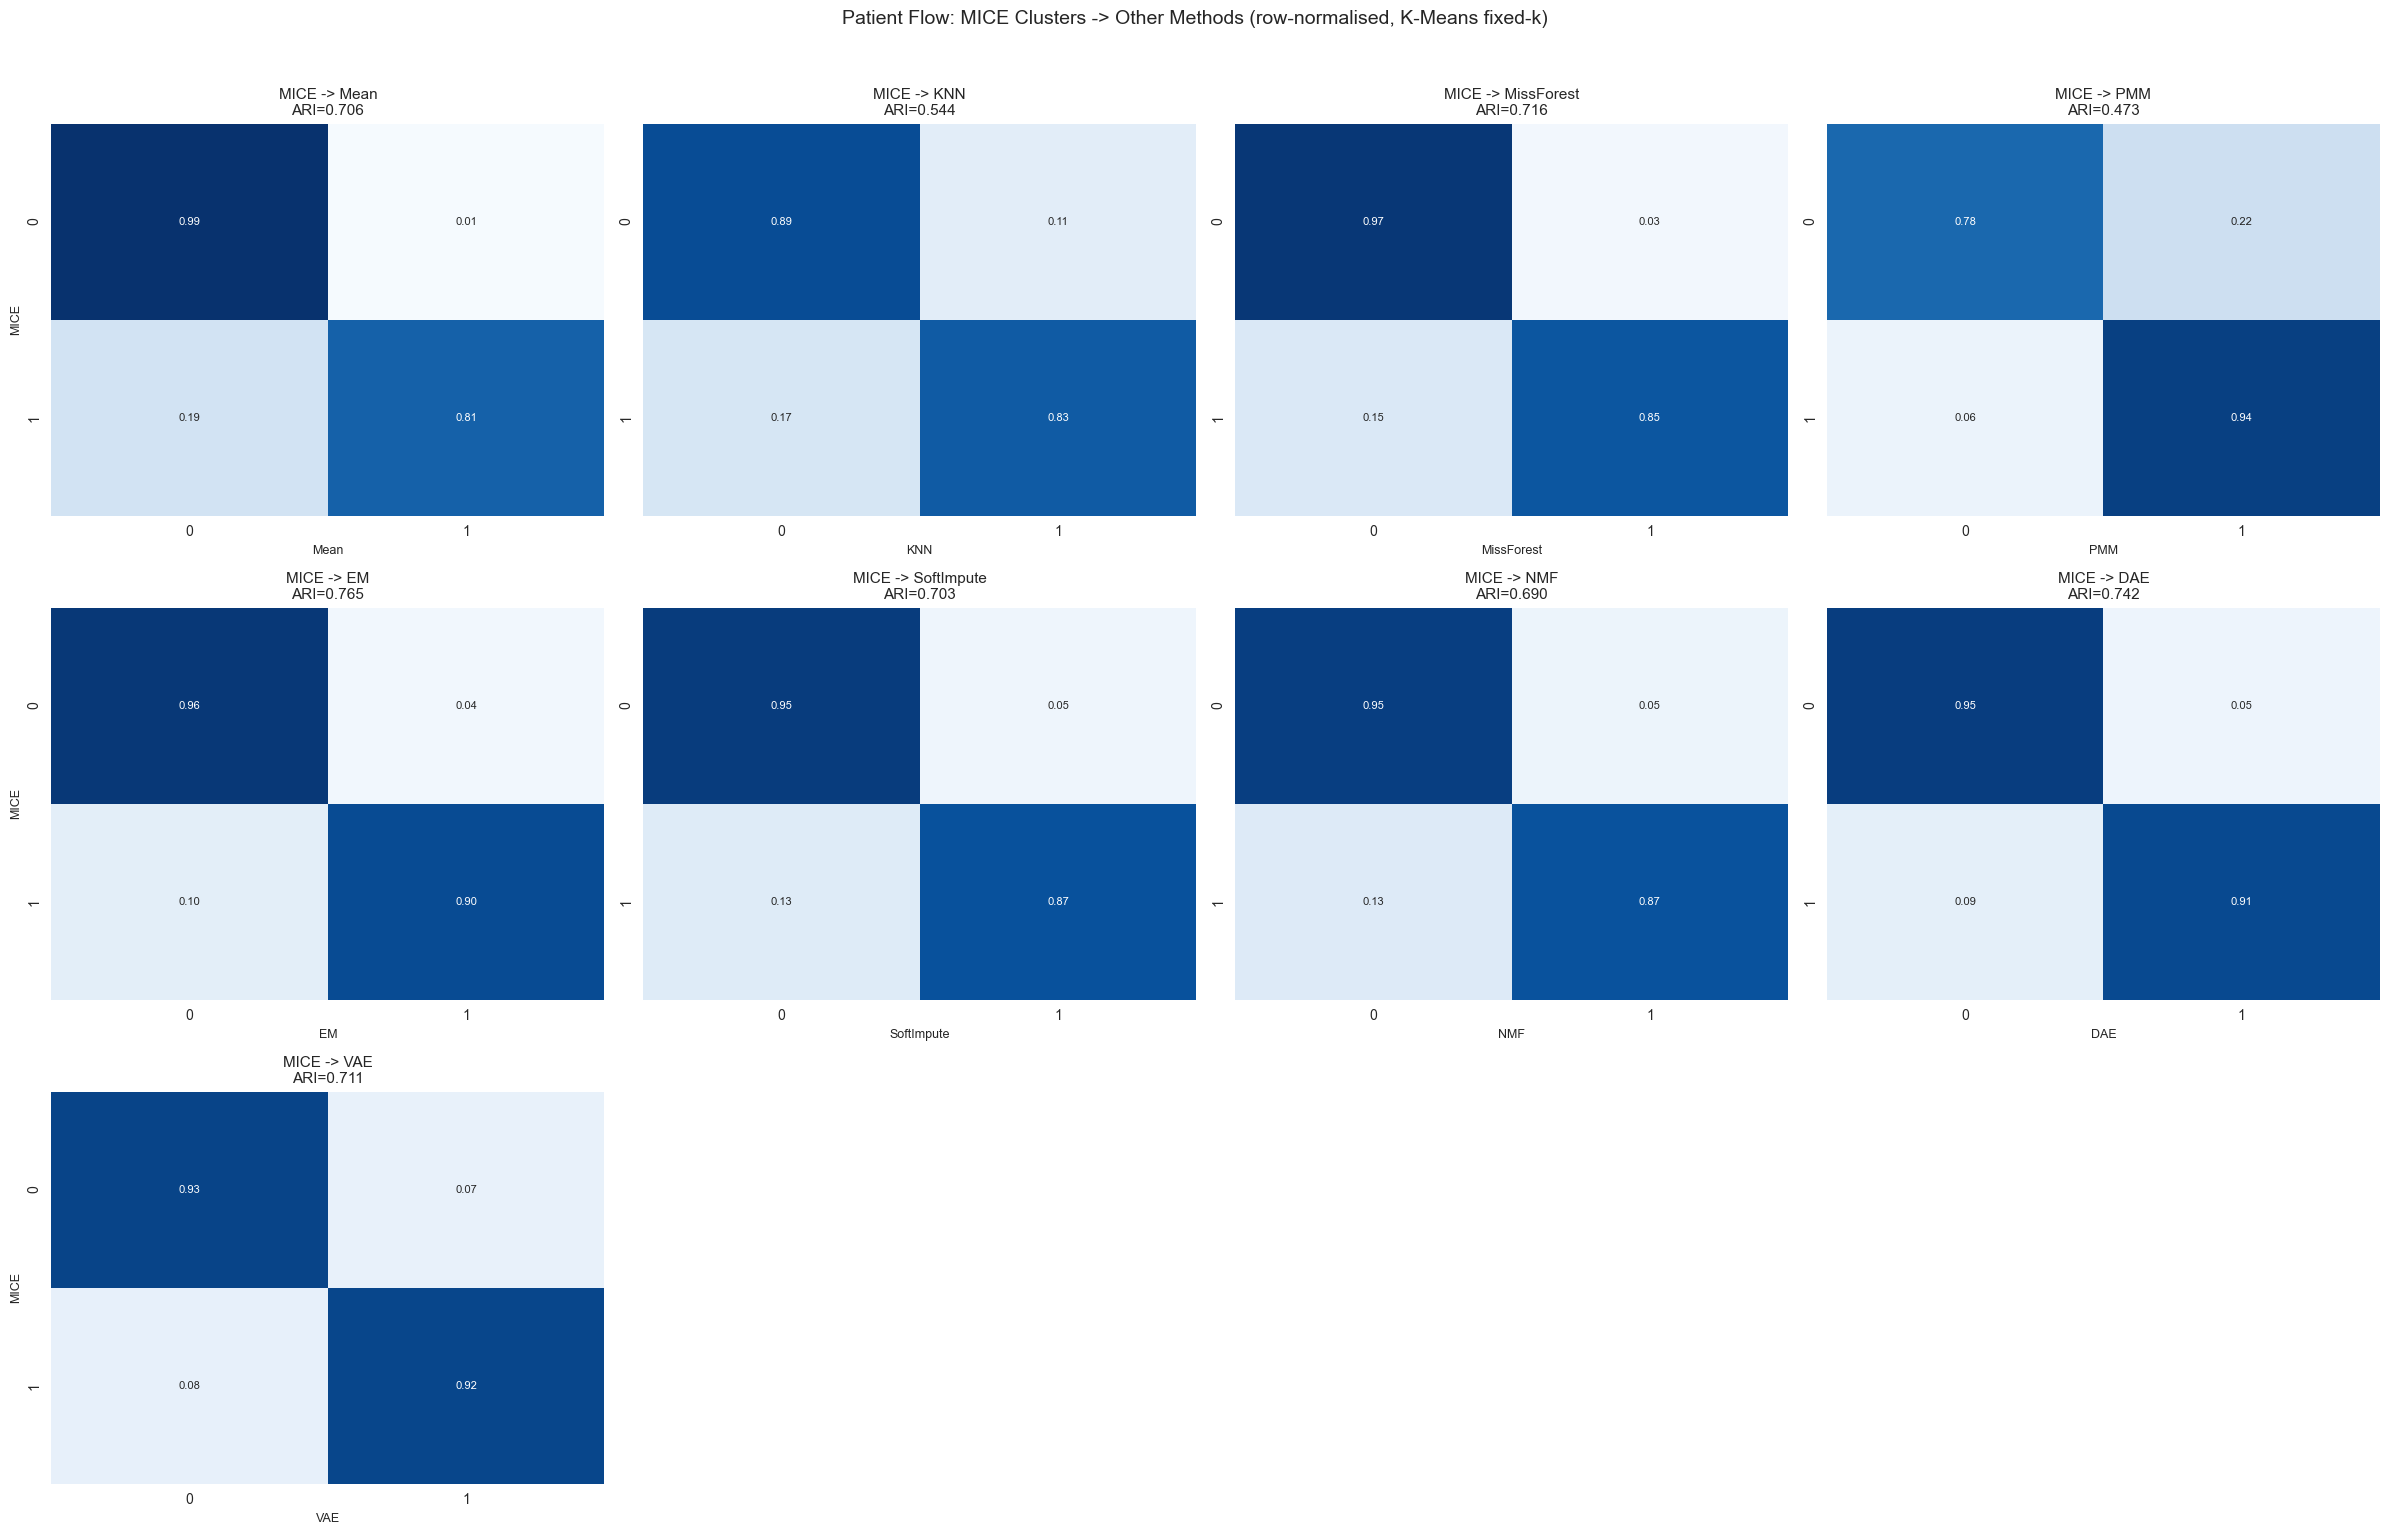

Saved: h2_patient_flow.png


In [11]:
# Patient flow: cross-tabulation heatmaps (MICE vs others) using fixed-k labels
ref_method = 'MICE'
other_methods = [m for m in METHODS if m != ref_method]
n_other = len(other_methods)

n_cols = 4
n_rows = (n_other + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 5 * n_rows))
axes = axes.flatten()

for idx, method in enumerate(other_methods):
    ax = axes[idx]
    
    # Cross-tab using aligned labels
    ct = pd.crosstab(
        pd.Series(aligned_labels[ref_method], name=f'{ref_method}'),
        pd.Series(aligned_labels[method], name=f'{method}'),
        margins=False
    )
    
    # Normalize by row (MICE cluster)
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    
    sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                ax=ax, cbar=False, annot_kws={'size': 8})
    ari_val = adjusted_rand_score(labels_h2[ref_method], labels_h2[method])
    ax.set_title(f'MICE -> {method}\nARI={ari_val:.3f}', fontsize=11)
    ax.set_xlabel(method, fontsize=9)
    ax.set_ylabel('MICE' if idx % n_cols == 0 else '', fontsize=9)

# Remove empty axes
for idx in range(n_other, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Patient Flow: MICE Clusters -> Other Methods (row-normalised, K-Means fixed-k)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h2_patient_flow.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h2_patient_flow.png')

## 7. Method Dendrogram

Hierarchical clustering of imputation methods based on ARI distance (1 - ARI) reveals which methods produce the most similar clustering solutions.

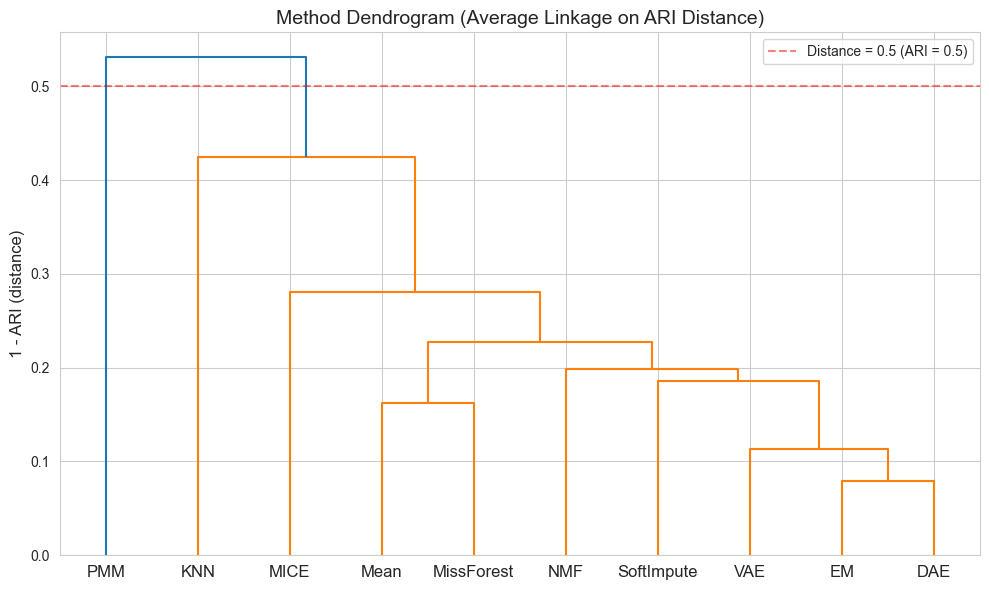

Saved: h2_method_dendrogram.png


In [12]:
# Method dendrogram from ARI distance
ari_distance = 1 - ari_matrix
np.fill_diagonal(ari_distance, 0)
ari_distance = (ari_distance + ari_distance.T) / 2  # Ensure symmetry
ari_distance = np.clip(ari_distance, 0, None)

condensed = squareform(ari_distance)
Z = linkage(condensed, method='average')

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Z, labels=METHODS, ax=ax, leaf_font_size=12, color_threshold=0.5)
ax.set_ylabel('1 - ARI (distance)', fontsize=12)
ax.set_title('Method Dendrogram (Average Linkage on ARI Distance)', fontsize=14)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Distance = 0.5 (ARI = 0.5)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h2_method_dendrogram.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h2_method_dendrogram.png')

## 8. Per-Domain Imputation Divergence

Coefficient of variation (CV) across imputation methods for each domain score quantifies which cognitive domains are most sensitive to imputation choice.

=== Per-Domain Imputation Divergence ===
                    mean_cv  median_cv  mean_std  mean_range
Executive Function   0.1362        0.0    2.8109      9.5717
Attention            0.1077        0.0    5.1264     17.6432
Memory               0.1030        0.0    1.1699      3.7696
Visuoperception      0.0513        0.0    0.9028      3.1177
Language             0.0450        0.0    0.5391      1.8312
Orientation          0.0413        0.0    0.4119      1.2668


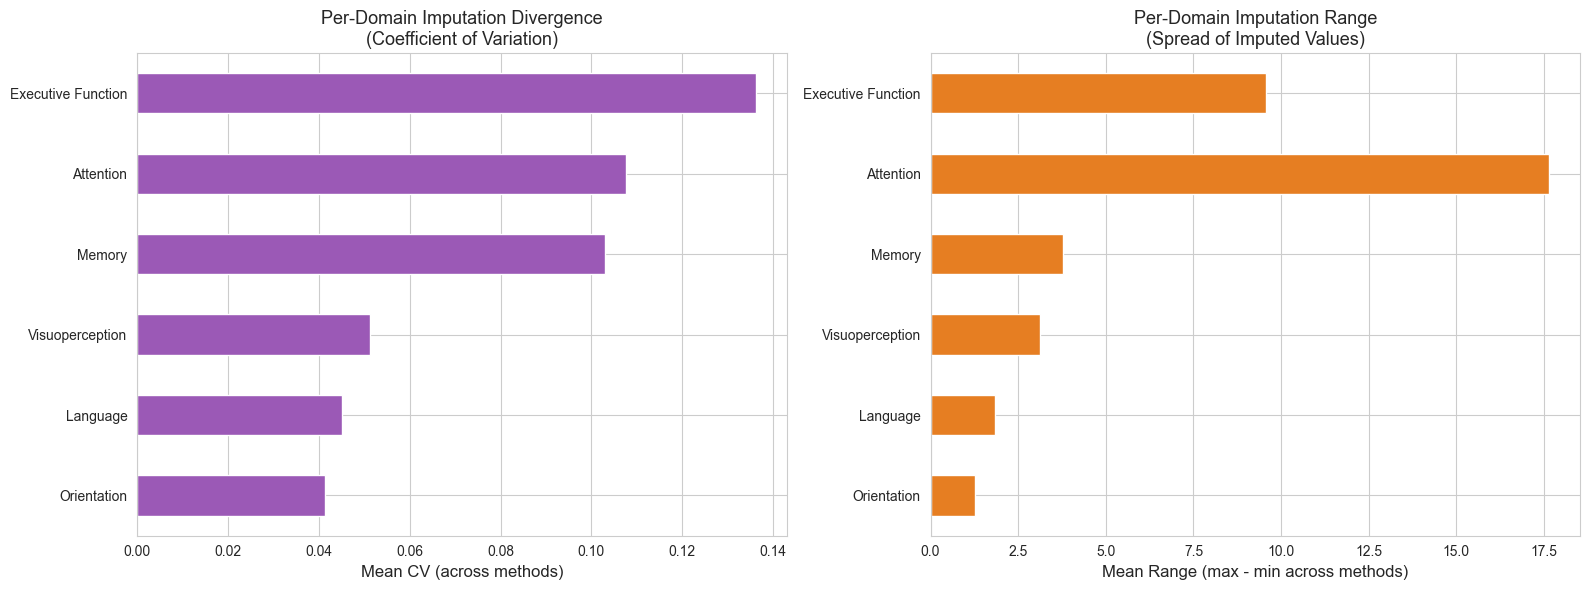

Saved: h2_domain_divergence.png


In [13]:
# Per-domain imputation divergence
domain_scores_all = {}
for m in METHODS:
    domain_scores_all[m] = pd.DataFrame(
        infra['domain_scores'][m],
        columns=infra['domain_score_columns'],
        index=infra['domain_score_index']
    )

domains_list = infra['domain_score_columns']
domain_divergence = {}

for domain in domains_list:
    # Stack scores across methods for each patient
    patient_scores = np.column_stack([domain_scores_all[m][domain].values for m in METHODS])
    # Coefficient of variation across methods for each patient
    means = np.abs(np.mean(patient_scores, axis=1))
    stds = np.std(patient_scores, axis=1)
    cv = stds / (means + 1e-10)
    domain_divergence[domain] = {
        'mean_cv': np.mean(cv),
        'median_cv': np.median(cv),
        'mean_std': np.mean(stds),
        'mean_range': np.mean(np.ptp(patient_scores, axis=1))
    }

div_df = pd.DataFrame(domain_divergence).T.sort_values('mean_cv', ascending=False)
print('=== Per-Domain Imputation Divergence ===')
print(div_df.round(4).to_string())

# Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

div_df['mean_cv'].plot(kind='barh', ax=ax1, color='#9b59b6', edgecolor='white')
ax1.set_xlabel('Mean CV (across methods)', fontsize=12)
ax1.set_title('Per-Domain Imputation Divergence\n(Coefficient of Variation)', fontsize=13)
ax1.invert_yaxis()

div_df['mean_range'].plot(kind='barh', ax=ax2, color='#e67e22', edgecolor='white')
ax2.set_xlabel('Mean Range (max - min across methods)', fontsize=12)
ax2.set_title('Per-Domain Imputation Range\n(Spread of Imputed Values)', fontsize=13)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'h2_domain_divergence.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: h2_domain_divergence.png')

In [14]:
# H2 Verdict (shared UMAP + K-Means fixed-k)
h2_result = {
    'hypothesis': 'H2: Imputation Robustness',
    'verdict': 'SUPPORTED' if median_ari > 0.50 else ('PARTIALLY SUPPORTED' if mean_ari > 0.30 else 'NOT SUPPORTED'),
    'mean_ari': round(mean_ari, 4),
    'median_ari': round(median_ari, 4),
    'mean_ari_excl_mean': round(mean_ari_nm, 4),
    'threshold': 0.50,
    'instability_corr_r': round(r, 3),
    'instability_corr_p': p_val,
    'consensus_confidence': round(mean_conf, 3),
    'high_confidence_pct': round((consensus_confidence > 0.75).sum() / n_patients * 100, 1),
    'domain_divergence': {d: round(v['mean_cv'], 4) for d, v in domain_divergence.items()}
}

print(f'\n{"="*60}')
print(f'H2 VERDICT: {h2_result["verdict"]}')
print(f'Mean pairwise ARI (all): {h2_result["mean_ari"]} (threshold: {h2_result["threshold"]})')
print(f'Median pairwise ARI (all): {h2_result["median_ari"]}')
print(f'Mean pairwise ARI (excl. Mean): {h2_result["mean_ari_excl_mean"]}')
print(f'Instability-imputation correlation: r={h2_result["instability_corr_r"]}')
print(f'Consensus confidence: {h2_result["consensus_confidence"]}')
print(f'High-confidence patients: {h2_result["high_confidence_pct"]}%')
print(f'{"="*60}')

# Save
with open(os.path.join(RESULTS_DIR, 'h2_results.pkl'), 'wb') as f:
    pickle.dump(h2_result, f, protocol=4)

ari_df.to_csv(os.path.join(RESULTS_DIR, 'ARI_Matrix.csv'))
nmi_df.to_csv(os.path.join(RESULTS_DIR, 'NMI_Matrix.csv'))
ari_df_nm.to_csv(os.path.join(RESULTS_DIR, 'ARI_Matrix_excl_Mean.csv'))

print('\n=== Notebook 6 Complete ===')


H2 VERDICT: SUPPORTED
Mean pairwise ARI (all): 0.6836 (threshold: 0.5)
Median pairwise ARI (all): 0.7164
Mean pairwise ARI (excl. Mean): 0.6769
Instability-imputation correlation: r=0.411
Consensus confidence: 0.945
High-confidence patients: 92.0%

=== Notebook 6 Complete ===
